# E9 241 Digital Image Processing - Assignment 5
***
*Submitted by: Dwaipayan Haldar*<br>
*S.R. No. : 27128*

In [1]:
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.decomposition import PCA

from src.P01_Feature_Extractor import *

## Problem 1: Feature Extraction with a Pretrained Model

### Problem 1.(a)

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print(f"Original shape: {x_train.shape}")
x_train_preprocessed = preprocess_input(x_train)
x_test_preprocessed = preprocess_input(x_test)

y_train_categorical = to_categorical(y_train, 10)
y_test_categorical = to_categorical(y_test, 10)

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

x = base_model.output
x = GlobalAveragePooling2D()(x)
    
feature_extractor = Model(inputs=base_model.input, outputs=x)
feature_extractor.trainable = False

features_train = feature_extractor.predict(x_train_preprocessed, batch_size=64)
features_test = feature_extractor.predict(x_test_preprocessed, batch_size=64)

print(f"Shape of extracted features: {features_train.shape}")

Original shape: (50000, 32, 32, 3)


2025-11-18 19:38:41.056144: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2025-11-18 19:38:41.056279: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-11-18 19:38:41.056283: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2025-11-18 19:38:41.056512: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-11-18 19:38:41.056536: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


  7/782 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step

2025-11-18 19:38:41.994133: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step
Shape of extracted features: (50000, 512)


### Problem 1.(b)

In [3]:
classifier = Sequential([Input(shape=(features_train.shape[1],)),Dense(10, activation='softmax')])
classifier.compile(optimizer='adam', loss='categorical_crossentropy',metrics=['accuracy'])

history = classifier.fit(features_train, y_train_categorical,epochs=30, batch_size=64,validation_data=(features_test, y_test_categorical))

Epoch 1/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.5075 - loss: 4.8187 - val_accuracy: 0.5769 - val_loss: 2.3659
Epoch 2/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6016 - loss: 1.7243 - val_accuracy: 0.6057 - val_loss: 1.5075
Epoch 3/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6137 - loss: 1.3641 - val_accuracy: 0.5988 - val_loss: 1.3718
Epoch 4/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6141 - loss: 1.3214 - val_accuracy: 0.6109 - val_loss: 1.3554
Epoch 5/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6130 - loss: 1.3210 - val_accuracy: 0.6156 - val_loss: 1.3279
Epoch 6/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6148 - loss: 1.3151 - val_accuracy: 0.6128 - val_loss: 1.3474
Epoch 7/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6123 - loss: 1.3234 - val_accuracy: 0.6091 - val_loss: 1.3531
Epoch 8/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6146 - loss: 1.3184 - val_accuracy: 0.

### Problem 1.(c)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6040 - loss: 1.3788

Final Test Accuracy: 60.40%


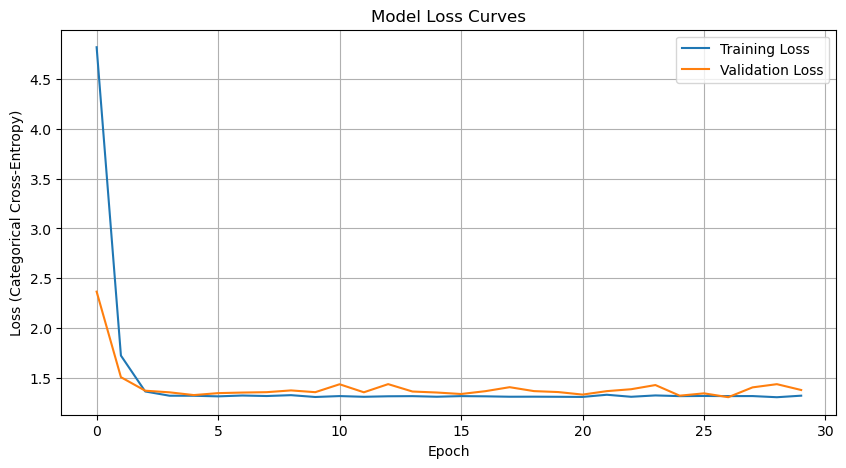

In [4]:
test_loss, test_accuracy = classifier.evaluate(features_test, y_test_categorical)
print(f"\nFinal Test Accuracy: {test_accuracy * 100:.2f}%")
plot_loss_curves(history)

## Problem 2: Domain Shift Evaluation and Fine-Tuning

### Problem 2.(a)

In [17]:
images = np.load("CIFAR-10-C/glass_blur.npy")
labels = np.load("CIFAR-10-C/labels.npy")

images_preprocessed = preprocess_input(images)
labels_categorical = to_categorical(labels, 10)

features_c = feature_extractor.predict(images_preprocessed, batch_size=64)

loss_c, accuracy_c = classifier.evaluate(features_c, labels_categorical)
print(f"Baseline Accuracy on Corrupted Data: {accuracy_c * 100:.2f}%")

782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.4582 - loss: 2.1311
Baseline Accuracy on Corrupted Data: 45.82%


### Problem 2.(b)

In [18]:
idx_train = np.random.choice(50000, size=20000, replace=False)
x_c_train_subset = images_preprocessed[idx_train]
y_c_train_subset = labels_categorical[idx_train]

base_model_ft = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
base_model_ft.trainable = False 

for layer in base_model_ft.layers:
    if 'block5' in layer.name:
        layer.trainable = True

x = GlobalAveragePooling2D()(base_model_ft.output)
output = Dense(10, activation='softmax')(x)
model_ft = Model(inputs=base_model_ft.input, outputs=output)

model_ft.layers[-1].set_weights(classifier.get_weights())

model_ft.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy',metrics=['accuracy'])

history_ft = model_ft.fit(x_c_train_subset,y_c_train_subset,epochs=10, batch_size=32)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.5958 - loss: 1.2083
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.7416 - loss: 0.7448
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.8395 - loss: 0.4943
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.9032 - loss: 0.3293
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.9465 - loss: 0.2140
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.9716 - loss: 0.1364
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.9873 - loss: 0.0856
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.9955 - loss: 0.0504
Epoch 9/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.9987 - loss: 0.0306
Epoch 10/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.9996 - loss: 0.0183


### Problem 2.(c)

In [19]:
loss_finetuned, accuracy_c_finetuned = model_ft.evaluate(images_preprocessed, labels_categorical)

print(f"Original Model Accuracy (Corrupted Data): {accuracy_c * 100:.2f}%")
print(f"Fine-Tuned Model Accuracy (Corrupted Data): {accuracy_c_finetuned * 100:.2f}%")


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.9300 - loss: 0.2666
Original Model Accuracy (Corrupted Data): 45.82%
Fine-Tuned Model Accuracy (Corrupted Data): 93.00%


## Problem 3: Feature Representation Analysis

### Problem 3.(a)

In [21]:
oplayer = model_ft.get_layer("global_average_pooling2d_2").output

feature_extractor_finetuned = Model(inputs = model_ft.input, outputs = oplayer)

features_cipar = feature_extractor.predict(x_train_preprocessed, batch_size=64)
features_cipar_finetuned = feature_extractor_finetuned.predict(x_train_preprocessed, batch_size=64)

features_cipar_c = feature_extractor.predict(images_preprocessed, batch_size=64)
features_cipar_c_finetuned = feature_extractor_finetuned.predict(images_preprocessed, batch_size=64)

782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step


### Problem 3.(b)

In [22]:
pca = PCA(n_components=2)
pca.fit(features_cipar)

features_cipar_pca = pca.transform(features_cipar)
features_cipar_finetuned_pca = pca.transform(features_cipar_finetuned)
features_cipar_c_pca = pca.transform(features_cipar_c)
features_cipar_c_finetuned_pca = pca.transform(features_cipar_c_finetuned)

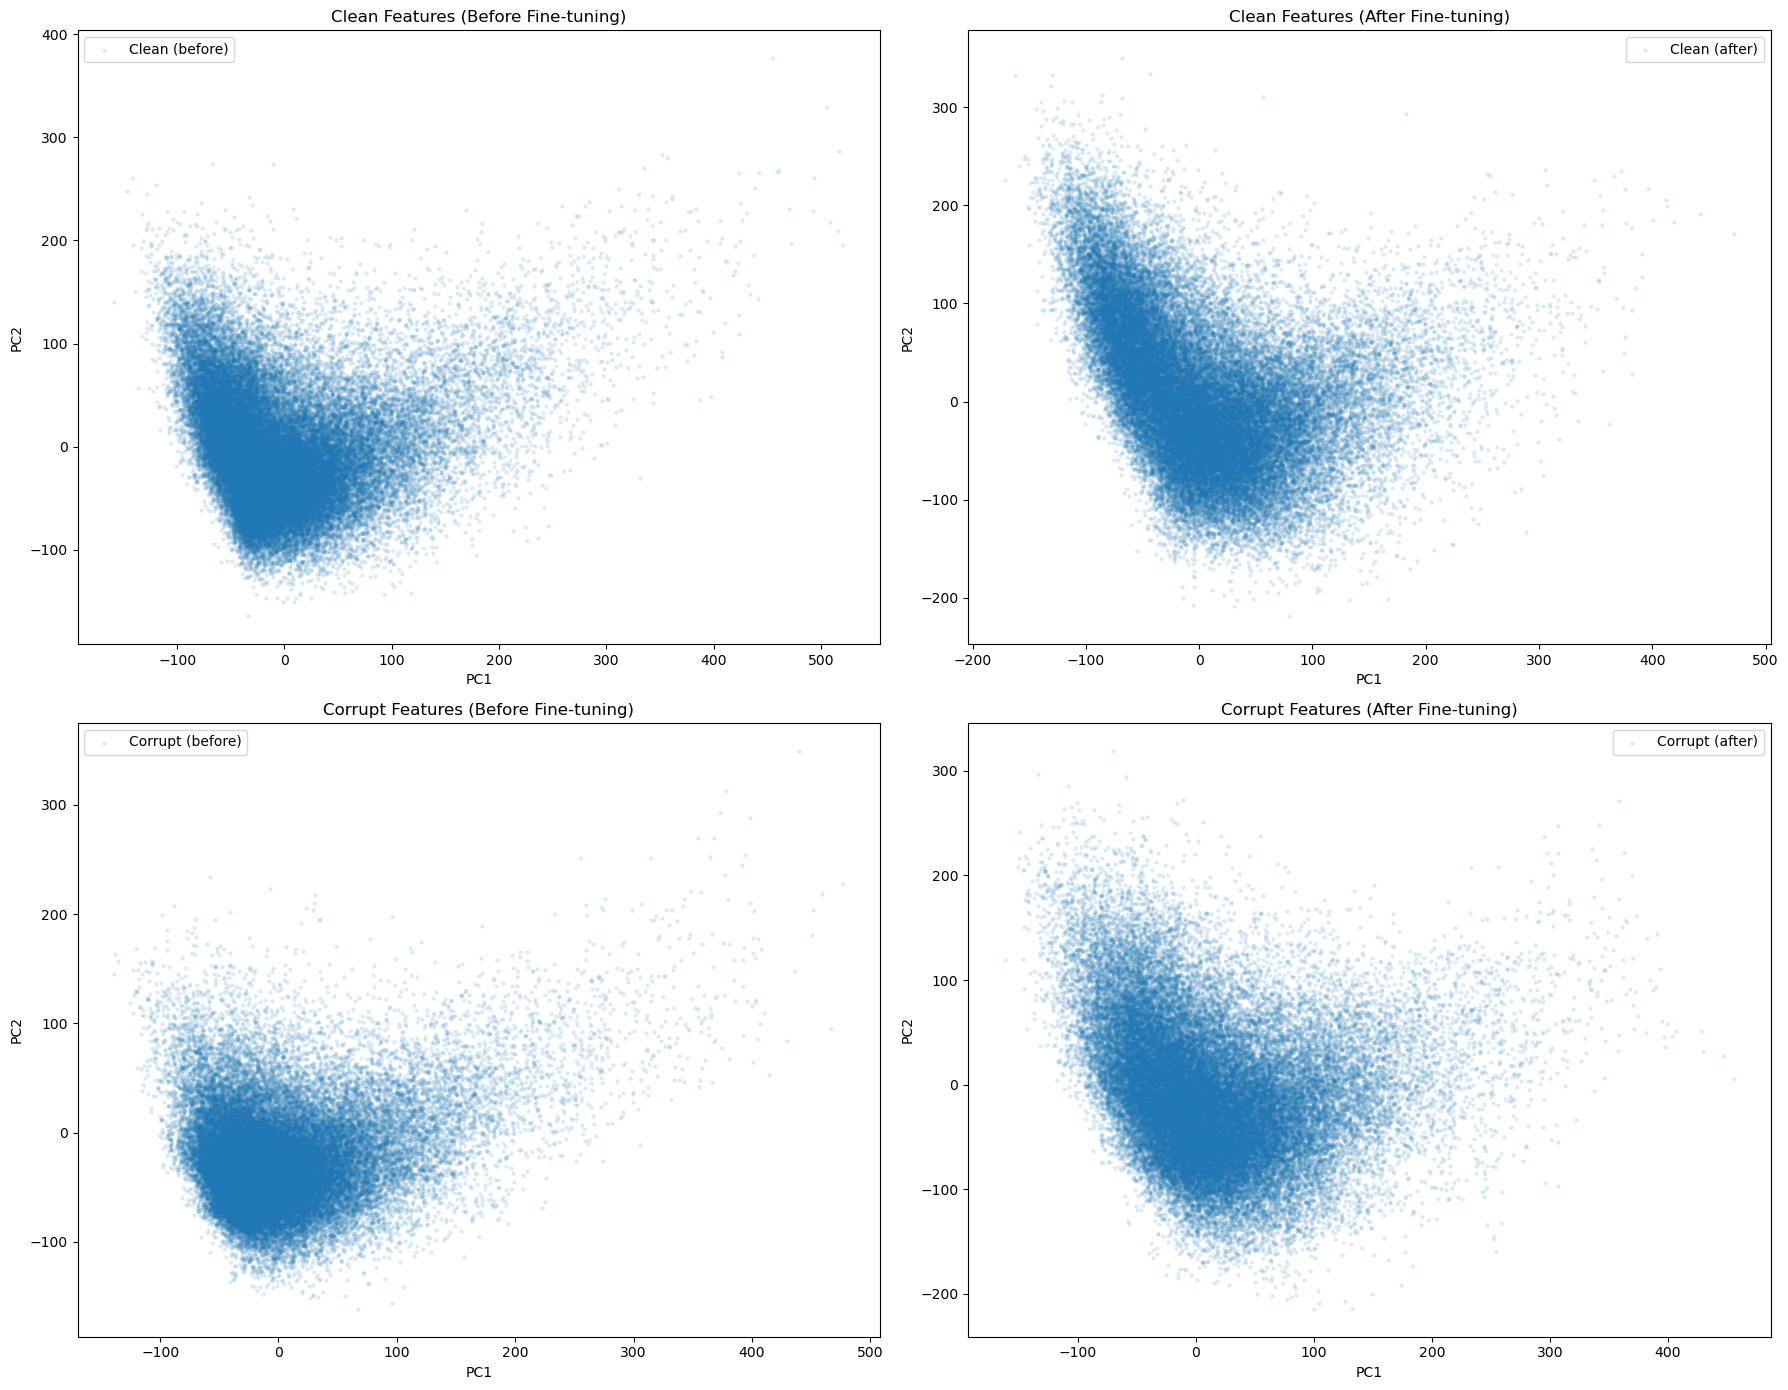

In [24]:
plt.figure(figsize=(18, 14))
plt.subplot(2, 2, 1)
plt.scatter(features_cipar_pca[:, 0], features_cipar_pca[:, 1], s=5, alpha=0.1, label="Clean (before)")
plt.title("Clean Features (Before Fine-tuning)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend()
plt.subplot(2, 2, 2)
plt.scatter(features_cipar_finetuned_pca[:, 0], features_cipar_finetuned_pca[:, 1],s=5, alpha=0.1, label="Clean (after)")
plt.title("Clean Features (After Fine-tuning)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend()
plt.subplot(2, 2, 3)
plt.scatter(features_cipar_c_pca[:, 0], features_cipar_c_pca[:, 1],s=5, alpha=0.1, label="Corrupt (before)")
plt.title("Corrupt Features (Before Fine-tuning)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend()
plt.subplot(2, 2, 4)
plt.scatter(features_cipar_c_finetuned_pca[:, 0], features_cipar_c_finetuned_pca[:, 1],s=5, alpha=0.1, label="Corrupt (after)")
plt.title("Corrupt Features (After Fine-tuning)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend()

plt.tight_layout()
plt.show()